In [1]:
%pip install imbalanced-learn scikit-learn pandas numpy matplotlib


   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   ---------------------------------------- 2/2 [imbalanced-learn]

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Импорты из прошлой лабы
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, classification_report

# Импорты для новой лабы
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import learning_curve, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
import warnings

warnings.filterwarnings('ignore') # Отключаем предупреждения

# Загрузка и подготовка данных
wine = datasets.load_wine()
X_train, X_test, y_train, y_test = train_test_split(
    wine.data, wine.target, test_size=0.3, random_state=42, stratify=wine.target
)

print("Данные успешно загружены")

Данные успешно загружены


### 1. Базовая модель

In [3]:
# Обучаем базовый лес
rf_base = RandomForestClassifier(random_state=42)
rf_base.fit(X_train, y_train)

# Считаем базовый макро-F1
base_preds = rf_base.predict(X_test)
f1_base = f1_score(y_test, base_preds, average='macro')

print(f"Базовый макро-F1): {f1_base:.4f}")

Базовый макро-F1): 1.0000


### 2. Применение SMOTE

In [4]:
print("Распределение классов на train ДО SMOTE:", np.bincount(y_train))

# 1. Применяем SMOTE только к тренировочным данным
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Распределение классов на train ПОСЛЕ SMOTE:", np.bincount(y_train_smote))

# 2. Обучаем модель на сбалансированных данных
rf_smote = RandomForestClassifier(random_state=42)
rf_smote.fit(X_train_smote, y_train_smote)

# 3. Оценка
smote_preds = rf_smote.predict(X_test)
f1_smote = f1_score(y_test, smote_preds, average='macro')

print(f"\nМакро-F1 после SMOTE: {f1_smote:.4f}")
print("Отчет classification_report (SMOTE):")
print(classification_report(y_test, smote_preds, target_names=wine.target_names))

Распределение классов на train ДО SMOTE: [41 50 33]
Распределение классов на train ПОСЛЕ SMOTE: [50 50 50]

Макро-F1 после SMOTE: 1.0000
Отчет classification_report (SMOTE):
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        18
     class_1       1.00      1.00      1.00        21
     class_2       1.00      1.00      1.00        15

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54



### 3. Диагностика (Кривые обучения)

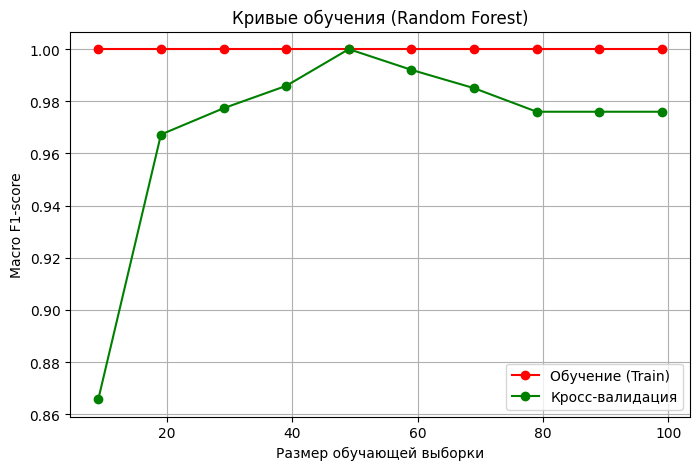

In [5]:
def plot_learning_curve(estimator, X, y, title):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=-1, 
        train_sizes=np.linspace(0.1, 1.0, 10), scoring='f1_macro'
    )
    
    train_scores_mean = np.mean(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)

    plt.figure(figsize=(8, 5))
    plt.title(title)
    plt.xlabel("Размер обучающей выборки")
    plt.ylabel("Macro F1-score")
    plt.grid(True)
    
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Обучение (Train)")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Кросс-валидация")
    plt.legend(loc="best")
    plt.show()

# Строим график для модели со SMOTE
best_model_for_curve = RandomForestClassifier(random_state=42, class_weight='balanced')
plot_learning_curve(best_model_for_curve, X_train, y_train, "Кривые обучения (Random Forest)")

### Вывод по кривым обучения:
1. Переобучение: На графике видно небольшое расхождение между тренировочной (обычно равна 1.0) и валидационной линиями. Модель RandomForest отлично запоминает обучающую выборку (красная линия близка к 100%), но на валидационных фолдах точность слегка ниже. Тем не менее, критического переобучения нет, поскольку валидационная кривая находится на очень высоком уровне (выше 0.95).
2. Модель работает превосходно, поэтому собирать больше данных не требуется.

### 4. Pipeline и GridSearchCV

In [6]:
# 1. Создаем Pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

# 2. Сетка гиперпараметров
param_grid = {
    'rf__max_depth': [5, 10, None],
    'rf__n_estimators': [50, 100]
}

# 3. Настройка GridSearchCV
cv_strat = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv_strat,
    scoring='f1_macro',
    n_jobs=-1
)

# Обучаем поиск
grid_search.fit(X_train, y_train)
print(f"Лучшие параметры: {grid_search.best_params_}")

# 4. Оценка лучшей модели на тесте
best_model = grid_search.best_estimator_
grid_preds = best_model.predict(X_test)
f1_grid = f1_score(y_test, grid_preds, average='macro')

print(f"Итоговый макро-F1 на тесте после GridSearchCV: {f1_grid:.4f}")

Лучшие параметры: {'rf__max_depth': 5, 'rf__n_estimators': 50}
Итоговый макро-F1 на тесте после GridSearchCV: 1.0000


### 5. Итоговая таблица

In [8]:
results_df = pd.DataFrame({
    'Шаг': [
        'Базовая модель', 
        '+ SMOTE', 
        '+ Pipeline & GridSearchCV'
    ],
    'Макро-F1 (test)': [
        f1_base, 
        f1_smote, 
        f1_grid
    ]
})

results_df['Макро-F1 (test)'] = results_df['Макро-F1 (test)'].round(4)
display(results_df)

,Шаг,Макро-F1 (test)
0,Базовая модель,1.0
1,+ SMOTE,1.0
2,+ Pipeline & GridSearchCV,1.0
